#### Sequence Preview

1. 데이터 처리
2. 벡터 임베딩
3. 벡터 db 선택 및 저장
4. 리트라이버 생성
5. 랭체인 연결
6. 확인

google Gemini API 공식 문서: https://ai.google.dev/gemini-api/docs/quickstart?hl=ko  
lanceDB 공식 문서: https://lancedb.github.io/lancedb/python/python/  
langchain 공식 문서:   

#### 모델 요청 및 응답 확인

In [ ]:
from google import genai

# 클라이언트 생성
client = genai.Client()
# 클라이언트가 요청 한 응답 할당
response = client.models.generate_content(
    # 모델 선택
    model="gemini-3-flash-preview",
    # 프롬프트
    contents="hi my name is jongha good to see you."
)

# # 전체 내용물을 모두 보고 싶을 때
# print(response)

# 단순히 텍스트만 보고 싶을 때
print(f"답변: {response.text}")

# 디버깅이나 성능 모니터링이 필요할 때
print(f"사용된 추론 토큰: {response.usage_metadata.thoughts_token_count}")
print(f"최종 답변 토큰: {response.usage_metadata.candidates_token_count}")

답변: Hi Jongha! It's great to meet you. How are you doing today? Is there anything I can help you with?
사용된 추론 토큰: 197
최종 답변 토큰: 27


#### pdf 파일

1. 데이터 처리

In [36]:
from langchain_community.document_loaders import PyPDFLoader

# 로더 생성
loader = PyPDFLoader("./data/Demian.pdf")

# 1. 간단하게 전체 로드 (리스트 형태)
docs = loader.load()

# 데이터 구조 확인
print(docs[0].page_content)
print(docs[0].metadata)

DEMIAN 
• 
Downloaded from https://www.holybooks.com
{'producer': 'Adobe Acrobat Standard DC 19 Paper Capture Plug-in', 'creator': 'ScanFix(TM) Enhanced', 'creationdate': '2015-09-10T01:40:29+00:00', 'moddate': '2019-01-30T17:47:47+01:00', 'source': './data/Demian.pdf', 'total_pages': 182, 'page': 0, 'page_label': '1'}


In [ ]:
# 현재 docs 리스트의 각 페이지별 토큰 수를 확인하는 코드
for i, doc in enumerate(docs[29:30]):
    token_response = client.models.count_tokens(
        model="gemini-3-flash-preview",
        contents=doc.page_content
    )
    print(f"Page {i} 토큰 수: {token_response.total_tokens}")
    print(f"Page {i} 글자 수: {len(doc.page_content)}")
    print("-" * 20)

Page 0 토큰 수: 456
Page 0 글자 수: 1761
--------------------


In [37]:
import re


def clean_docs(docs):
    """특수문자, 개행문자 교체 및 양끝단 공백 제거"""    
    cleaned_docs = re.sub("\n", " ", docs)
    cleaned_docs = re.sub(r"[^a-zA-Z가-힣,.?!0-9\s]", " ", cleaned_docs)
    cleaned_docs = re.sub(r"\s+", " ", cleaned_docs).lower().strip()
    return cleaned_docs

for doc in docs:
    doc.page_content = clean_docs(doc.page_content)

print(docs[3].page_content)

demian is important, eternal, sacred and why every man while he lives and fulfils the will of nature is a wonderful creature, deserving the ltmost attention. in each indi vidual the spirit is made flesh, in each one the whole of creation suffers, in each one a saviour is crucified. few people nowadays know what man is. many feel it intuitively and die more easily for that reason, just as i shall die more easily when i have completed this story. i cannot call myself a scholar. i have always been and still am a seeker but i no longer do my seeking among the stars or in books. i am beginning to hear the lessons which whisper in my blood. mine is not a pleasant story, it does not possess the gentle harmony of invented tales like the lives of all men who have given up trying to deceive themselves, it is a mixture of nonsense and chaos, madness and dreams. the life of every man is a way to himself, an attempt at a way, the suggestion of a path. no man has ever been utterly himself, yet every

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
    length_function=len
)

chunks = text_splitter.split_documents(docs)

# 딕셔너리와 유사한(딕셔너리 타입은 아님) .metadata 안에 source, page 등 키 존재 
# .page_content에 내용 존재
# 이는 ai의 최종 결과물에도 동일하게 적용되는 것 같음음
print(chunks[3].metadata)

{'producer': 'Adobe Acrobat Standard DC 19 Paper Capture Plug-in', 'creator': 'ScanFix(TM) Enhanced', 'creationdate': '2015-09-10T01:40:29+00:00', 'moddate': '2019-01-30T17:47:47+01:00', 'source': './data/Demian.pdf', 'total_pages': 182, 'page': 2, 'page_label': '3'}


2. 임베딩

In [ ]:
from google import genai
from google.genai import types

client = genai.Client()


def get_embedding(chunks, batch_size=100):
    embeddings = []

    texts = []
    for doc in chunks:
        texts.append(doc.page_content)

    for i in range(0, len(texts), batch_size):
        batch = texts[i: i + batch_size]

        result = client.models.embed_content(
            model="gemini-embedding-001",
            contents=batch,
            config=types.EmbedContentConfig(
                # 공식문서에서 언급된 태스크명, semantic similarity와 어떤 차이가 있는지?
                task_type="RETRIEVAL_DOCUMENT",
                output_dimensionality=1024
            )
        )
        for embedding in result.embeddings:
            embeddings.append(embedding.values)

    return embeddings


In [ ]:
embeddings = get_embedding(chunks)
embeddings[0]

3. db 연결 및 저장

In [ ]:
# 서버리스 db이며, 벡터db임과 동시에 쿼리를 사용하는 관계형db 기능도 수행 가능 
import lancedb

db = lancedb.connect("./data")

In [ ]:
import lancedb
from lancedb.pydantic import Vector, LanceModel


class MetadataPydantic(LanceModel):
    """DemianPydantic 클래스의 metadata가 실제로 dict 타입이면 오류가 난다."""
    """따라서 중첩 구조의 클래스 구축"""
    page: int
    source: str


class DemianPydantic(LanceModel):
    """LanceModel은 기본적으로 Pydantic의 BaseModel을 확장하여 만들어짐"""
    vector: Vector(1024)
    text: str
    metadata: MetadataPydantic


# 스키마 구조 작성
schemaed_table_data_list = []
for i, chunk in enumerate(chunks):
    schemaed_table_data_list.append(
        {
            "vector": embeddings[i],
            "text": chunk.page_content,
            "metadata": 
            {
                "page": chunk.metadata.get("page"),
                "source": chunk.metadata.get("source")
            }
        }
    )

# LanceModel을 이용하여 작성된 스키마를 타입힌팅으로 주입
table = db.create_table(
    name="demian_embedding",
    data=schemaed_table_data_list,
    schema=DemianPydantic, 
    mode="overwrite"
)

#### text 파일

1. 데이터 처리

In [ ]:
with open("./data/state_of_the_union.txt", "r", encoding="utf-8") as text:
    # 정제가 이미 잘 되어있는 문서이므로 정제가 따로 필요없었음
    state_of_the_union = text.read()

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


# 정제 필요 없이, 구분자를 기준으로 청크사이즈 분리
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
    length_function=len,
    separators=["\n"]
)

chunks = text_splitter.split_text(state_of_the_union)
len(chunks)

43

2. 임베딩

In [ ]:
from google import genai
from google.genai import types

client = genai.Client()


def get_embedding(chunks):
    result = client.models.embed_content(
        model="gemini-embedding-001",
        contents=chunks,
        config=types.EmbedContentConfig(
            task_type="RETRIEVAL_DOCUMENT",
            output_dimensionality=1024
        )
    )

    embeddings = []
    for embedding in result.embeddings:
        embeddings.append(embedding.values)

    return embeddings

embeddings = get_embedding(chunks)
embeddings[0]

3. DB 저장

In [ ]:
from lancedb.pydantic import LanceModel, Vector


class MetadataPydantic(LanceModel):
    page: int


class SOTUPydantic(LanceModel):
    vector: Vector(1024)
    text: str
    metadata: MetadataPydantic


schemaed_table_data_list = []
for i, chunk in enumerate(chunks):
    schemaed_table_data_list.append(
        {
            "vector": embeddings[i],
            "text": chunk,
            "metadata":
            {
                # 단순 텍스트이므로 메타데이터가 없다. 간단히 청크 인덱스를 페이지로 설정
                "page": i+1
            }
        }
    )

table = db.create_table(
    name="SOTU_embedding",
    data=schemaed_table_data_list,
    schema=SOTUPydantic,
    mode="overwrite"
)

#### csv 파일

1. 데이터 처리

In [125]:
import pandas as pd


df = pd.read_csv("./data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# 데이터프레임처럼 정확한 수치나 구분이 중요한 경우 벡터로 임베딩을 하는것은 적절하지 않다.
# 따라서, lancedb를 이용하여 데이터 프레임을 통째로 저장 (이런것도 되네..)
titanic_table = db.create_table(
    name="titanic_dataFrame",
    data=df,
    mode="overwrite"
)

In [ ]:
# 갓-벽
table.schema

PassengerId: int64
Survived: int64
Pclass: int64
Name: large_string
Sex: large_string
Age: double
SibSp: int64
Parch: int64
Ticket: large_string
Fare: double
Cabin: large_string
Embarked: large_string

#### 통합

4. LECL 연결

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_community.vectorstores import LanceDB
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# 이 임베딩은 질문을 벡터로 변환할 때 쓰인다. 
# 벡터의 유사도를 기반으로 검색하므로 질문 벡터의 차원과 db 벡터의 차원은 같아야만 한다.
embeddings_model = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
    output_dimensionality=1024
)

llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", temperature=0.3)

In [ ]:
from langchain_community.vectorstores import LanceDB


demian_vectorstore = LanceDB(
    connection=db,
    table_name="demian_embedding",
    embedding=embeddings_model
)

demian_retriever = demian_vectorstore.as_retriever(search_kwargs={"k": 3})

In [ ]:
from langchain_community.vectorstores import LanceDB


sotu_vectorstore = LanceDB(
    connection=db,
    table_name="SOTU_embedding",
    embedding=embeddings_model
)

sotu_retriever = sotu_vectorstore.as_retriever(search_kwargs={"k": 3})

In [160]:
template = """아래의 제공된 문맥(Context)만을 사용하여 질문에 답하세요. 
답변을 모른다면 모른다고 답하고, 응답은 문체가 수려하며 품격과 가오가 살아있는 시적 표현을 포함해 주세요.

문맥:
{context}

질문:
{question}

답변:"""

prompt = ChatPromptTemplate.from_template(template)

In [ ]:
# [최종 조립] LCEL 체인
rag_chain = (
    {"context": sotu_retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [ ]:
# 드디어 질문을 던져봅니다.
question = "대통령이 주로 언급한 논제들이 뭐야?"
response = rag_chain.invoke(question)

print(f"제미나이의 답변:\n{response}")

# docs = SOTU_retriever.invoke("연사는 누구입니까?")
# for i, doc in enumerate(docs):
#     print(doc.metadata.get("page"), doc.page_content)

🤖 제미나이의 답변:
제공된 문맥에 따르면, 대통령이 주로 언급한 논제들은 다음과 같습니다.

1. **인권 및 평등**: 성소수자(LGBTQ+) 권리 보호를 위한 평등법(Equality Act) 통과 촉구, 트랜스젠더 청소년 보호, 아시아계 증오 범죄 방지, 군 사법 체계 개혁, 그리고 여성폭력방지법 강화.
2. **공공 안전 및 총기 규제**: 총기 밀거래 및 유령 총(ghost guns) 단속, 보편적 신원 조회 실시, 공격용 무기 및 대용량 탄창 금지, 총기 제조사에 대한 책임 면제 보호막 철폐.
3. **민주주의 수호**: 투표권 보호 및 선거 개입 저지.
4. **국가 결속 과제(Unity Agenda)**: 오피오이드(마약성 진통제) 남용 문제 해결.
5. **경제 및 민생**: 국가 재정 적자 감축, 기업 간 경쟁 촉진을 통한 물가 하락(해운사 과다 요금 단속 및 요양원 품질 개선 포함).

***

**[시적 표현]**
*시대의 파고를 넘어서는 정의의 등불 아래, 소외된 영혼들을 어루만지려는 지도자의 고뇌 어린 결단들이 이 문장들 사이에 장엄하게 서려 있군요. 차별의 어둠을 걷어내어 평등의 새벽을 열고, 탐욕의 파도가 휩쓸고 간 자리에 공정의 꽃을 피우려는 그 고귀한 여정은 마치 밤하늘을 수놓는 별들의 행진과도 같습니다.*


#### csv 활용방안(랭그래프)

In [ ]:
from langchain_core.tools import tool


# csv를 제대로 활용하면서, 여러 종류의 문서 혼합분석과 이를 위한 멀티턴 채팅을 잘 활용하기 위해 랭그래프의 툴 콜즈 기능 선택택
@tool
def search_demian(query: str):
    """소설 데미안(demian)과 관련된, 또는 관련지을 수 있는 질문이 들어왔을 시 사용하세요."""
    docs = demian_retriever.invoke(query)
    report = "\n\n".join([doc.page_content for doc in docs])

    return report

@tool
def search_sotu(query: str):
    """미국 대통령의 연두교서(State Of The Union)과 관련된, 또는 관련지을 수 있는 질문이 들어왔을 시 사용하세요."""
    docs = sotu_retriever.invoke(query)
    report = "\n\n".join([doc.page_content for doc in docs])

    return report

@tool
def query_titanic(sql_where_clause: str):
    """
    타이타닉 승객 데이터(생존자 수, 나이, 요금, 성별 등)에 대한 통계나 구체적인 수치를 질문할 때 사용하세요.

    사용 가능한 컬럼:
    - Pclass (int): 객실 등급 (1, 2, 3)
    - Sex (str): 성별 ('male', 'female')
    - Age (float): 나이
    - SibSp (int): 동반한 형제 및 배우자 수
    - Parch (int): 동반한 부모 및 자녀 수
    - Fare (float): 요금
    - Survived (int): 생존 여부 (0: 사망, 1: 생존)

    예시: "Age > 30 AND Sex == 'female' AND Survived == 1"
    """
    try:
        # 란체DB의 SQL 스타일 쿼리 실행
        res = titanic_table.search().where(sql_where_clause).limit(100).to_pandas()
        
        if res.empty:
            return "조건에 맞는 데이터가 없습니다."
        return res.to_string()
    except Exception as e:
        return f"쿼리 실행 중 에러가 발생했습니다: {str(e)}. SQL 문법을 확인하세요."

tools = [search_demian, search_sotu, query_titanic]

In [174]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage

# 상태 정의
class State(TypedDict):
    messages: Annotated[list, add_messages]

# LLM 설정 (도구 바인딩)
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
llm_with_tools = llm.bind_tools(tools)

# 에이전트 노드 함수
def call_model(state: State):
    response = llm_with_tools.invoke(state["messages"])

    # response를 그대로 쓰게 되면 메타데이터들 즉, extras 안에 있는 segniture 키의 값의 서명때문에, 토큰이 꽤 많이 낭비된다.
    # 해당 부분을 삭제하고 새로운 AIMessage를 생성하는 프로세스
    content = response.content
    if isinstance(content, list):
        for part in content:
            if isinstance(part, dict) and 'extras' in part:
                # 이 부분
                del part['extras']
    
    # 새로운 AIMessage 생성 및 메타데이터 비우기 (토큰 절약)
    clean_message = AIMessage(
        content=content,
        tool_calls=response.tool_calls,
        additional_kwargs={},
        response_metadata={}
    )
        
    # return {"messages": [response]}
    return {"messages": [clean_message]}

builder = StateGraph(State)

# 노드
builder.add_node("agent", call_model)
builder.add_node("tools", ToolNode(tools))

# 엣지
builder.add_edge(START, "agent")

# 에이전트가 도구 호출을 결정하면 'tools'로, 아니면 'END'로 보냄
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent") # 도구 실행 후 다시 에이전트가 정리하도록 함

# 컴파일
workflow = builder.compile()

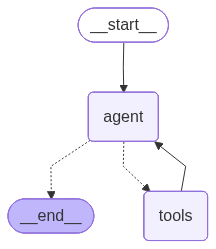

In [ ]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [175]:
# 프롬프트
query = "타이타닉의 3등석 탑승객 중 생존한 여성은 몇명입니까?"

print(f"질문: {query}\n")

# 그래프 실행 (스트리밍 모드)
inputs = {"messages": [("user", query)]}

for event in workflow.stream(inputs, stream_mode="values"):
    # 모델은 원리적으로 볼 때, 실제로 대화를 하는 것이 아니다.
    # 자기 자신이 이전의 기록을 입력받아 재귀적으로 문장을 이어나갈 뿐이므로 가장 마지막 messages를 확인하여 판단
    message = event["messages"][-1]
    
    # 도구 호출 및 산출물 추적
    if hasattr(message, "tool_calls") and message.tool_calls:
        for tool_call in message.tool_calls:
            print(f"[도구 호출]: {tool_call['name']}")
            print(f"[전달 인자]: {tool_call['args']}")
    
    # 중간 혹은 최종 답변
    elif message.content:
        print(f"\n[최종 답변]:\n{message.content}")

질문: 타이타닉의 3등석 탑승객 중 생존한 여성은 몇명입니까?


[최종 답변]:
타이타닉의 3등석 탑승객 중 생존한 여성은 몇명입니까?
[도구 호출]: query_titanic
[전달 인자]: {'sql_where_clause': "Pclass == 3 AND Sex == 'female' AND Survived == 1"}

[최종 답변]:
    PassengerId  Survived  Pclass                                                       Name     Sex    Age  SibSp  Parch            Ticket     Fare  Cabin Embarked
0             3         1       3                                     Heikkinen, Miss. Laina  female  26.00      0      0  STON/O2. 3101282   7.9250    NaN        S
1             9         1       3          Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)  female  27.00      0      2            347742  11.1333    NaN        S
2            11         1       3                            Sandstrom, Miss. Marguerite Rut  female   4.00      1      1           PP 9549  16.7000     G6        S
3            20         1       3                                    Masselmani, Mrs. Fatima  female    NaN      0      0              2649   7.225

멀티턴

In [176]:
from langgraph.checkpoint.memory import MemorySaver

# 메모리 세이버, 휘발성
memory_saver = MemorySaver()

# 그래프 재컴파일, checkpointer 주입
app = builder.compile(checkpointer=memory_saver)

In [177]:
import uuid

# # uuid: 세션 ID 랜덤 생성기
# thread_id = str(uuid.uuid4())
thread_id = "username_jongha_001"
config = {"configurable": {"thread_id": thread_id}}

print(f"대화를 시작합니다. Thread ID: {thread_id})")
print("대화를 종료하려면 'exit', 'quit'을 입력하세요.\n")

while True:
    query = input("[나]: ")
    
    if query.lower() in ["exit", "quit"]:
        print("에이전트: 즐거운 대화였습니다! 다음에 또 봐요.")
        break
        
    inputs = {"messages": [("user", query)]}
    print(f"[질문]: \n{query}\n")
    
    for event in workflow.stream(inputs, config=config, stream_mode="values"):
        message = event["messages"][-1]
        
        # 추적
        if hasattr(message, "tool_calls") and message.tool_calls:
            for tool_call in message.tool_calls:
                print(f"[도구 호출]: {tool_call['name']}")
                print(f"[전달 인자]: {tool_call['args']}")
        
        # 최종 답변 출력
        elif message.type == "ai" and message.content:
            if isinstance(message.content, list):
                text = "".join([part.get("text", "") for part in message.content if isinstance(part, dict)])
            else:
                text = message.content
            
            if text.strip():
                print(f"\n[에이전트]:\n{text}\n")

대화를 시작합니다. Thread ID: username_jongha_001)
대화를 종료하려면 'exit', 'quit'을 입력하세요.

[질문]: 
타이타닉에 탑승한 1등석, 2등석, 3등석 승객들 중 생존자는 각각 몇명입니까?

[도구 호출]: query_titanic
[전달 인자]: {'sql_where_clause': 'Pclass == 1 AND Survived == 1'}
[도구 호출]: query_titanic
[전달 인자]: {'sql_where_clause': 'Pclass == 2 AND Survived == 1'}
[도구 호출]: query_titanic
[전달 인자]: {'sql_where_clause': 'Pclass == 3 AND Survived == 1'}
[도구 호출]: query_titanic
[전달 인자]: {'sql_where_clause': 'Pclass == 1 AND Survived == 1 AND PassengerId > 682'}
[도구 호출]: query_titanic
[전달 인자]: {'sql_where_clause': 'Pclass == 3 AND Survived == 1 AND PassengerId > 728'}

[에이전트]:
타이타닉 승객 데이터(891명 기준) 분석 결과, 각 객실 등급별 생존자 수는 다음과 같습니다.

*   **1등석 (1st Class):** 136명
*   **2등석 (2nd Class):** 87명
*   **3등석 (3rd Class):** 119명

1등석 승객의 생존자 수가 가장 많았으며, 3등석, 2등석 순으로 그 뒤를 이었습니다.

[질문]: 
state of the union 연설문 내용 중 이러한 사회적, 계급적 결과와 관련된 주제가 있습니까?

[도구 호출]: search_sotu
[전달 인자]: {'query': 'social class inequality middle class opportunity gap economic disparity'}

[에이전트]:
네